In [41]:
import rasterio as rs

#### 瓦片无地理参考警告
c:\envs\miniforge3\envs\gis\Lib\site-packages\rasterio\__init__.py:317: **NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.**

dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)

In [42]:
data = rs.open('http:/127.0.0.1/tile/1/1/0.png')

In [43]:
data.indexes

(1, 2, 3)

In [44]:
data.name

'http:///127.0.0.1/tile/1/1/0.png'

In [45]:
data.mode

'r'

In [46]:
data.count

3

In [47]:
data.width, data.height

(256, 256)

In [48]:
data.bounds

BoundingBox(left=0.0, bottom=256.0, right=256.0, top=0.0)

In [49]:
data.crs

In [50]:
data.transform

Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0)

## 瓦片坐标转换

In [51]:
import math

def num2deg(xtile, ytile, zoom):
    n = 1 << zoom
    lon_deg = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat_deg = math.degrees(lat_rad)

    return lon_deg, lat_deg


def num2extent(xtile, ytile, zoom):
    # 左上坐标
    x0y0 = num2deg(xtile, ytile, zoom)
    # 右下坐标
    x1y1 = num2deg(xtile + 1, ytile + 1, zoom)
    
    return x0y0, x1y1

In [52]:
num2extent(1, 1, 1)

((0.0, 0.0), (180.0, -85.0511287798066))

In [53]:
num2deg(2,1,1)

(180.0, 0.0)

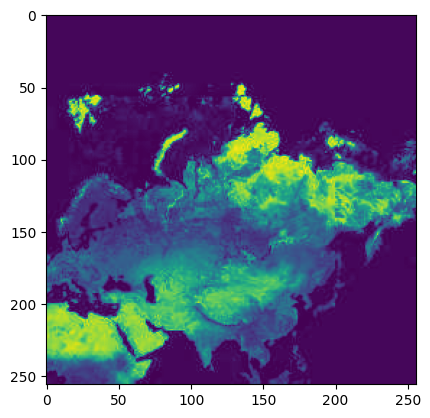

In [54]:
from matplotlib import pyplot
pyplot.imshow(data.read(1))
pyplot.show()